# Région convective : covariance $u'w'$ et comparaison à Romps (2014)

**Deux objectifs.**

1. **Comprendre la covariance de la région convective.** D'où vient $\overline{u'w'}$ ? À quels
   niveaux est-elle grosse, et pourquoi ? On la décompose par catégorie (up / dn / env) et on la
   visualise par scatterplots $(u',w')$ pour distinguer ce qui relève d'un *transport organisé*
   (séparation des moyennes entre catégories) de ce qui relève d'une *corrélation interne*.

2. **Comparer ma modélisation à celle de Romps (2014).** Point méthodologique central, soulevé
   à la relecture : **il est faux de comparer le flux de Reynolds *total* au seul flux de masse
   *montant*.** Le flux de masse, en tant que quantité conservative, met en jeu *tous* les
   courants (montant, descendant, environnement) dont les flux de masse se compensent
   ($\sum_k\sigma_k\bar w_k=0$). Cette partie repart donc sur des bases correctes : on écrit le
   flux de masse complet, on situe précisément ce que Romps néglige (les descendances) et ce
   qu'il garde (la subsidence compensatoire de l'environnement), puis on confronte les deux
   cadres.

---
**Acquis des notebooks précédents (non re-démontré ici).** La décomposition exacte
$\Phi_{rey}=T_1(\text{organisé})+T_2(\text{sous-maille})$ ferme le budget au zéro machine, avec
$T_1\sim56\,\%$, $T_2\sim44\,\%$. On part de là pour *expliquer* et *comparer*, pas pour
re-prouver l'identité.

## 0 — Setup commun

On recharge la grille Méso-NH `large300`, l'état stationnaire (`t_stat`), les masques
humide/sec (PRW) et la densité de référence $\rho_0(z)$. **Toute l'analyse porte sur la région
humide**, où la convection profonde domine.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import xarray as xr
import gc, os

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv
DIR_3D, DIR_2D, DIR_1D = '3D', '2D', '1D'
def path3d(v): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{v}.nc')
print('Pret.')

Pret.


In [3]:
# --- dimensions + altitude ---
_ds = xr.open_dataset(path3d('ua')); _da = _ds['ua']
dim_t, dim_z, dim_y, dim_x = _da.dims[:4]
n_t, n_z = _da.sizes[dim_t], _da.sizes[dim_z]
_ds.close(); del _ds, _da; gc.collect()

_ds1 = xr.open_dataset(path1d('ua_avg'))
alt  = _ds1.altitude.values.copy()
_ds1.close(); del _ds1; gc.collect()

t_stat = int(2*n_t/3)
print(f'{n_t} t x {n_z} z   |  altitude {alt[0]:.0f}-{alt[-1]:.0f} m   |  t_stat={t_stat}')

100 t x 74 z   |  altitude 0-32500 m   |  t_stat=66


In [4]:
# --- masques humide/sec via PRW ---
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load(); ds_prw.close()
prw_mean  = prw_all.isel({dim_t: slice(t_stat,None)}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))
mh = (prw_mean.values > PRW_SEUIL); ms = ~mh
f_h, f_s = mh.mean(), ms.mean()
del prw_all; gc.collect()
print(f'Humide {f_h*100:.1f}%   Sec {f_s*100:.1f}%')

Humide 42.3%   Sec 57.7%


In [5]:
# --- densite de reference rho0(z) ---
BLOC = 2
rho0_sum = np.zeros(n_z); n_rho = 0
ds_ta = xr.open_dataset(path3d('ta')); ds_pa = xr.open_dataset(path3d('pa')); ds_hus = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T  = ds_ta['ta'].isel(sl).values; p = ds_pa['pa'].isel(sl).values; qv = ds_hus['hus'].isel(sl).values
    Tv = T*(1+qv/EPSILON)/(1+qv); rho = p/(Rd*Tv)
    rho0_sum += rho.mean(axis=(0,2,3))*(t1-t0); n_rho += (t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); del ds_ta,ds_pa,ds_hus; gc.collect()
rho0 = rho0_sum/n_rho
print(f'rho0 surface {rho0[0]:.3f}  ~10km {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')

rho0 surface 1.183  ~10km 0.410 kg/m3


### Un seul outil de découpage pour tout le notebook

Pour éviter de réécrire 36 fois la même boucle, on définit **une fonction de classification**
identique partout. À un niveau et un instant donnés, on partitionne la colonne convective en
trois catégories à partir d'un seuil $w_s = \max(w_{0},\,C\,\sigma_w)$ :

- **up**  : $w > w_s$    (ascendances / cœurs convectifs)
- **dn**  : $w < -w_s$   (descendances)
- **env** : $|w|\le w_s$ (environnement quasi-immobile)

C'est le **même seuil $C$** qui pilote la détection chez Romps (1 courant : up vs reste) et chez
moi (2 courants : up, dn, env). Garder une définition unique rend les deux modèles strictement
comparables.

In [6]:
W0_MIN_DEFAULT = 0.001   # plancher du seuil (m/s), evite ws=0 si sigma_w->0

def classify(w, C, w0=W0_MIN_DEFAULT):
    """Renvoie (ws, up, dn, env) pour un vecteur w (1D, points de la region humide)."""
    ws  = max(w0, C*w.std())
    up  = w >  ws
    dn  = w < -ws
    env = np.abs(w) <= ws
    return ws, up, dn, env

def cond_mean(x, msk, fallback):
    return x[msk].mean() if msk.any() else fallback

# indices utiles pour les diagnostics (troposphere libre 2-18 km)
def band(z0=2000, z1=18000):
    return slice(np.searchsorted(alt, z0), np.searchsorted(alt, z1))

def nse(truth, pred, s):
    a, b = truth[s], pred[s]; ok = np.isfinite(a) & np.isfinite(b)
    return 1 - np.nansum((a[ok]-b[ok])**2) / np.nansum((a[ok]-np.nanmean(a[ok]))**2)

print('classify / cond_mean / band / nse  -> OK')

classify / cond_mean / band / nse  -> OK


# Objectif 1 — Comprendre la covariance de la région convective

On veut répondre à trois questions :
1. **Pourquoi** y a-t-il une covariance $\overline{u'w'}\ne 0$ ? (qui la porte : up, dn, env ?)
2. **Où** (en altitude) est-elle grosse, et pourquoi ?
3. **Comment** se présente le nuage $(u',w')$ : elliptique (corrélation réelle) ou circulaire
   (bruit) ?

## 1.1 — Profil de covariance décomposé par catégorie

On calcule le profil $\rho_0\overline{u'w'}(z)$ **total**, puis la contribution de chaque
catégorie au sens *exact* : pour la catégorie $k$ de fraction surfacique $\sigma_k$,

$$\rho_0\overline{u'w'} \;=\; \sum_{k\in\{up,dn,env\}}
\underbrace{\rho_0\,\sigma_k(\bar u_k-\bar u)(\bar w_k-\bar w)}_{\text{organisé }T_1^k}
\;+\;\underbrace{\rho_0\,\sigma_k\,\langle(u-\bar u_k)(w-\bar w_k)\rangle_k}_{\text{interne }T_2^k}.$$

Cette identité (déjà validée au zéro machine dans les notebooks précédents) sert ici de
**grille de lecture physique** : elle dit *quelle catégorie* et *quel mécanisme* (transport
organisé vs corrélation interne) fabriquent la covariance, niveau par niveau.

In [7]:
# ---------------------------------------------------------------------------
# Profil de covariance total + decomposition par categorie (up/dn/env) x (T1/T2)
# ---------------------------------------------------------------------------
reg = mh; C = 0.5

rey = np.full(n_z, np.nan)
T1 = {k: np.full(n_z, np.nan) for k in ('up','dn','env')}
T2 = {k: np.full(n_z, np.nan) for k in ('up','dn','env')}
sig_prof = {k: np.full(n_z, np.nan) for k in ('up','dn','env')}

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a_re = 0.0
    a1 = {k:0.0 for k in T1}; a2 = {k:0.0 for k in T2}; asg = {k:0.0 for k in T1}; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub, wb, N = u.mean(), w.mean(), u.size
        a_re += ((u-ub)*(w-wb)).mean()
        ws, up, dn, env = classify(w, C)
        for k, msk in (('up',up),('dn',dn),('env',env)):
            if not msk.any(): continue
            sig = msk.sum()/N
            uu, ww = u[msk], w[msk]; uc, wc = uu.mean(), ww.mean()
            a1[k] += sig*(uc-ub)*(wc-wb)              # transport organise
            a2[k] += sig*((uu-uc)*(ww-wc)).mean()     # covariance interne
            asg[k] += sig
        n += 1; del u, w
    rey[iz] = rho0[iz]*a_re/n
    for k in T1:
        T1[k][iz] = rho0[iz]*a1[k]/n
        T2[k][iz] = rho0[iz]*a2[k]/n
        sig_prof[k][iz] = asg[k]/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

T1tot = sum(T1.values()); T2tot = sum(T2.values())
s = band()
print(f'controle |rey-(T1+T2)| max = {np.nanmax(np.abs((rey-(T1tot+T2tot))[s])):.2e}  (doit ~0)')
print(f'part T1 (organise)    mediane = {np.nanmedian((T1tot/rey)[s]):.2f}')
print(f'part T2 (sous-maille) mediane = {np.nanmedian((T2tot/rey)[s]):.2f}')

controle |rey-(T1+T2)| max = 1.27e-09  (doit ~0)
part T1 (organise)    mediane = 0.56
part T2 (sous-maille) mediane = 0.44


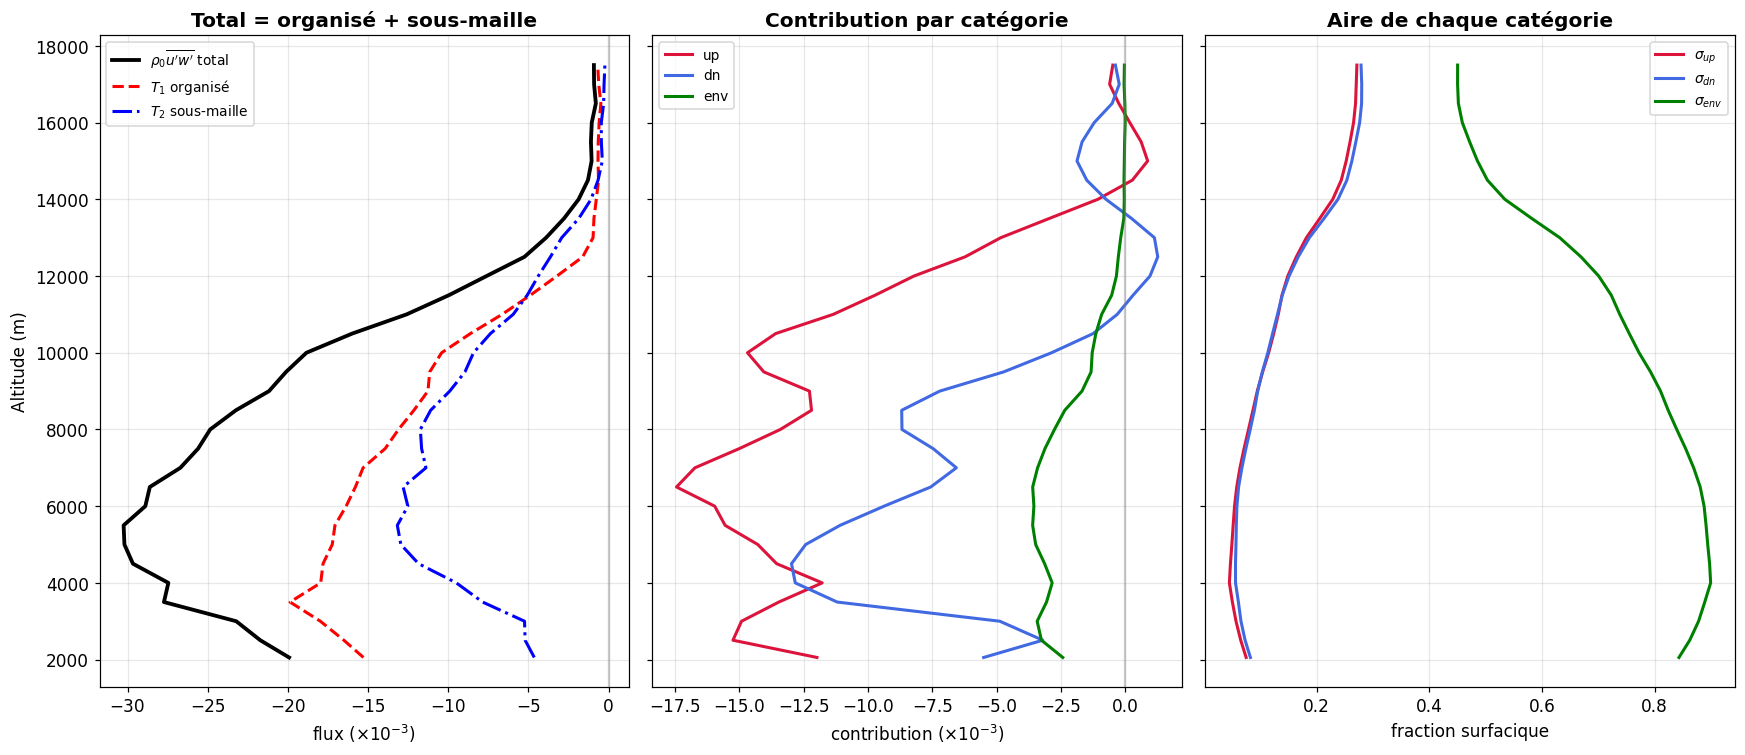

In [8]:
# --- figure : profils, contributions par categorie, fraction surfacique ---
s = band(); zf = alt[s]; sc = 1e3
fig, ax = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

# (a) total = organise + sous-maille
ax[0].plot(rey[s]*sc,   zf, 'k',  lw=2.5, label=r"$\rho_0\overline{u'w'}$ total")
ax[0].plot(T1tot[s]*sc, zf, 'r--',lw=2,   label=r'$T_1$ organisé')
ax[0].plot(T2tot[s]*sc, zf, 'b-.',lw=2,   label=r'$T_2$ sous-maille')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Total = organisé + sous-maille', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

# (b) qui porte la covariance ? (T1+T2 par categorie)
col = {'up':'crimson','dn':'royalblue','env':'green'}
for k in ('up','dn','env'):
    ax[1].plot((T1[k]+T2[k])[s]*sc, zf, color=col[k], lw=2, label=k)
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'contribution ($\times10^{-3}$)')
ax[1].set_title('Contribution par catégorie', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

# (c) fraction surfacique
for k in ('up','dn','env'):
    ax[2].plot(sig_prof[k][s], zf, color=col[k], lw=2, label=fr'$\sigma_{{{k}}}$')
ax[2].set_xlabel('fraction surfacique'); ax[2].set_title('Aire de chaque catégorie', fontweight='bold')
ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Interprétation — qui porte la covariance, et où 

Contrôle numérique : $|{\rm rey}-(T_1+T_2)|_{\max}=1.3\times10^{-9}$ (identité exacte),
**$T_1=56\,\%$, $T_2=44\,\%$** en médiane.

À lire sur la figure (région humide) :

- **Panneau (a).** Le flux total est négatif partout dans la troposphère libre (jusqu'à
  $-30\times10^{-3}$ vers 5–6 km) : la convection transporte de la quantité de mouvement
 vers le bas — c'est le « freinage » convectif (l'amortissement de type Rayleigh étudié par
  Romps). $T_1$ et $T_2$  sont tous deux négatifs et du même ordre :
  la covariance vient à la fois de la séparation des moyennes entre catégories *et* d'une
  corrélation résiduelle interne.
- **Panneau (b)** Les up (rouge) et les dn (bleu) contribuent
  du même signe (négatif). Ce n'est pas une compensation : une ascendance qui monte un
  déficit de $u$ et une descendance qui descend un excès de $u$ produisent toutes deux un
  flux vers le bas. L'environnement (vert) est quasi nul. C'est déjà la raison pour laquelle
  comparer le Reynolds total au seul courant montant n'a pas de sens : on amputerait la moitié
  du transport.
- **Panneau (c).** up et dn occupent chacun $\sim$10–25 % de la surface (croissant vers le bas),
  l'environnement le reste : transport intermittent porté par des cœurs peu étendus mais
  intenses.

## 1.2 — Où la covariance est-elle grosse, et pourquoi ?

On a établi *qui* porte la covariance ; reste *pourquoi elle varie avec l'altitude*. On
décompose la covariance interne de chaque catégorie en
$\langle u'w'\rangle_k = r_k \cdot \sigma_{u,k}\,\sigma_{w,k}$ (corrélation × amplitudes) et on
cherche, par corrélation verticale niveau-à-niveau, lequel de ces trois facteurs gouverne $|T_2|$.
La figure de contrôle qui suit (§ identité $r_0\sigma_u\sigma_w$) montre visuellement le résultat :
**c'est l'amplitude qui bouge, la corrélation reste plate.**

|T2| maximal a z = 5500 m   (T2 = -13.177 e-3)
  qui domine a ce niveau : up=-6.23, dn=-3.31, env=-3.63 (e-3)

--- up : corr. verticale de |T2_up| avec chaque facteur ---
        r_k : r = -0.77
    sigma_u : r = -0.04
    sigma_w : r = +0.75
    sigma_k : r = -0.69
      su*sw : r = +0.82

--- dn : corr. verticale de |T2_dn| avec chaque facteur ---
        r_k : r = -0.93
    sigma_u : r = -0.49
    sigma_w : r = +0.87
    sigma_k : r = -0.81
      su*sw : r = +0.84

--- env : corr. verticale de |T2_env| avec chaque facteur ---
        r_k : r = -0.98
    sigma_u : r = -0.91
    sigma_w : r = +0.68
    sigma_k : r = +0.89
      su*sw : r = +0.09


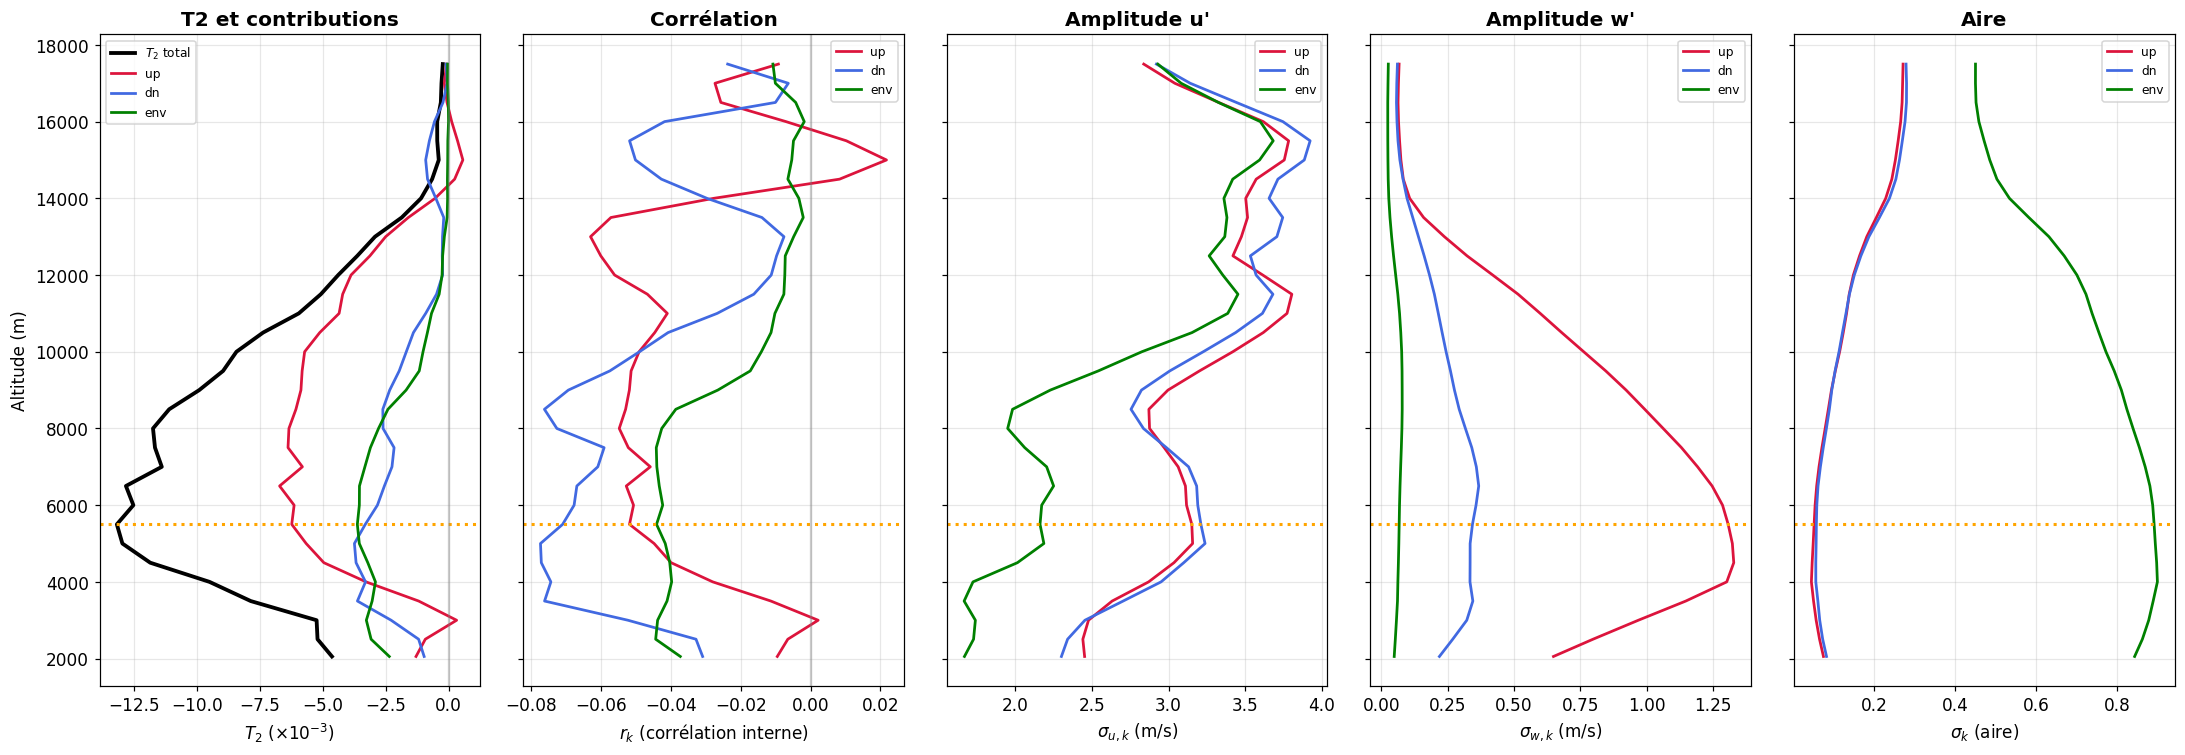

In [9]:
# ============================================================================
# COMPRENDRE T2 : T2_k = rho0 * sigma_k * <u'w'>_k = rho0 * sigma_k * r_k * sigma_u_k * sigma_w_k
#   -> a quel facteur (correlation interne r_k / amplitudes sigma_u,sigma_w / aire sigma_k)
#      doit-on l'augmentation de |T2|, et a quel niveau grossit-il ?
# ============================================================================
reg = mh; C = float(C)
cats = ('up', 'dn', 'env')
T2_k  = {k: np.full(n_z, np.nan) for k in cats}   # rho0*sig*<u'w'>_k
r_k   = {k: np.full(n_z, np.nan) for k in cats}   # correlation interne
su_k  = {k: np.full(n_z, np.nan) for k in cats}   # std interne de u
sw_k  = {k: np.full(n_z, np.nan) for k in cats}   # std interne de w
sig_k = {k: np.full(n_z, np.nan) for k in cats}   # fraction surfacique

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    acc = {k: dict(T2=0., r=0., su=0., sw=0., sig=0.) for k in cats}; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        N = u.size
        ws, up, dn, env = classify(w, C)
        for k, msk in (('up',up), ('dn',dn), ('env',env)):
            if msk.sum() < 5: continue
            uu, ww = u[msk], w[msk]
            up_ = uu - uu.mean(); wp_ = ww - ww.mean()   # anomalies INTERNES a la categorie
            sig = msk.sum()/N
            cov = (up_*wp_).mean(); su = up_.std(); sw = wp_.std()
            acc[k]['T2']  += rho0[iz]*sig*cov
            acc[k]['r']   += cov/(su*sw + 1e-12)
            acc[k]['su']  += su; acc[k]['sw'] += sw; acc[k]['sig'] += sig
        n += 1; del u, w
    for k in cats:
        T2_k[k][iz]=acc[k]['T2']/n; r_k[k][iz]=acc[k]['r']/n
        su_k[k][iz]=acc[k]['su']/n; sw_k[k][iz]=acc[k]['sw']/n; sig_k[k][iz]=acc[k]['sig']/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

T2_tot = sum(T2_k.values()); s = band()
iz_max = s.start + int(np.nanargmax(np.abs(T2_tot[s])))
print(f"|T2| maximal a z = {alt[iz_max]:.0f} m   (T2 = {T2_tot[iz_max]*1e3:+.3f} e-3)")
print("  qui domine a ce niveau : " + ", ".join(f"{k}={T2_k[k][iz_max]*1e3:+.2f}" for k in cats) + " (e-3)")

# --- quel facteur pilote les variations verticales de |T2| ? (correlation niveau-a-niveau) ---
for k in cats:
    tgt = np.abs(T2_k[k][s])
    fac = {'r_k':r_k[k][s], 'sigma_u':su_k[k][s], 'sigma_w':sw_k[k][s],
           'sigma_k':sig_k[k][s], 'su*sw':su_k[k][s]*sw_k[k][s]}
    print(f"\n--- {k} : corr. verticale de |T2_{k}| avec chaque facteur ---")
    for name, arr in fac.items():
        ok = np.isfinite(arr) & np.isfinite(tgt)
        print(f"   {name:>8} : r = {np.corrcoef(arr[ok], tgt[ok])[0,1]:+.2f}")

# --- figure : les ingredients de T2 par categorie ---
zf = alt[s]; col = {'up':'crimson','dn':'royalblue','env':'green'}
fig, ax = plt.subplots(1, 5, figsize=(20, 7), sharey=True)
ax[0].plot(T2_tot[s]*1e3, zf, 'k', lw=2.5, label=r'$T_2$ total')
for k in cats: ax[0].plot(T2_k[k][s]*1e3, zf, color=col[k], lw=1.8, label=k)
ax[0].axhline(alt[iz_max], color='orange', ls=':', lw=2); ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'$T_2$ ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('T2 et contributions', fontweight='bold'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
for k in cats: ax[1].plot(r_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[1].axhline(alt[iz_max], color='orange', ls=':', lw=2); ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'$r_k$ (corrélation interne)'); ax[1].set_title('Corrélation', fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
for k in cats: ax[2].plot(su_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[2].axhline(alt[iz_max], color='orange', ls=':', lw=2)
ax[2].set_xlabel(r'$\sigma_{u,k}$ (m/s)'); ax[2].set_title("Amplitude u'", fontweight='bold')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
for k in cats: ax[3].plot(sw_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[3].axhline(alt[iz_max], color='orange', ls=':', lw=2)
ax[3].set_xlabel(r'$\sigma_{w,k}$ (m/s)'); ax[3].set_title("Amplitude w'", fontweight='bold')
ax[3].legend(fontsize=8); ax[3].grid(alpha=.3)
for k in cats: ax[4].plot(sig_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[4].axhline(alt[iz_max], color='orange', ls=':', lw=2)
ax[4].set_xlabel(r'$\sigma_k$ (aire)'); ax[4].set_title('Aire', fontweight='bold')
ax[4].legend(fontsize=8); ax[4].grid(alpha=.3)
plt.tight_layout(); plt.show()

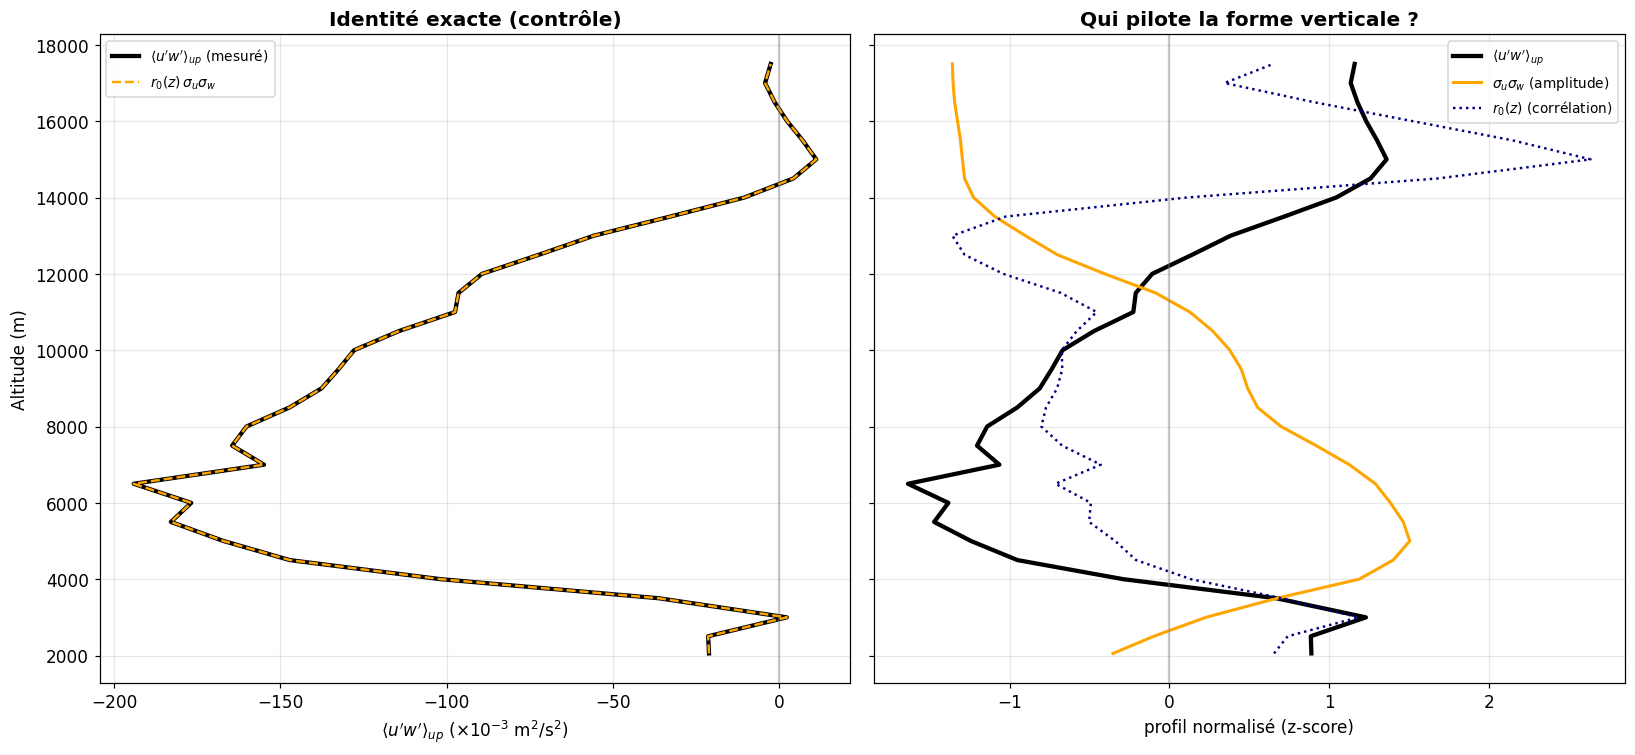

niveaux exploitables       = 32 / 32
residu max |cov - r0*amp|  = 6.74e-14  (doit ~0)
r0 median                  = -0.0428
corr verticale(|cov|, amp) = +0.87


In [10]:
# ============================================================================
# Verification de l'identite  <u'w'>_up = r0(z) * sigma_u,up * sigma_w,up
#   r0(z) := <u'w'>_up / (sigma_u sigma_w)  (correlation interne, par construction)
#   On recalcule cov_up / su_up / sw_up par une boucle propre (anomalies INTERNES
#   aux updrafts), independante des variables de la cellule precedente.
# ============================================================================
reg = mh; C = 0.5

cov_up = np.full(n_z, np.nan)   # <u'w'>_up  (covariance interne des updrafts)
su_up  = np.full(n_z, np.nan)   # sigma_u dans les updrafts
sw_up  = np.full(n_z, np.nan)   # sigma_w dans les updrafts

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    acov = asu = asw = 0.0; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ws, up, dn, env = classify(w, C)
        if up.sum() >= 5:
            uu, ww = u[up], w[up]
            up_ = uu - uu.mean()           # anomalie u DANS les updrafts
            wp_ = ww - ww.mean()           # anomalie w DANS les updrafts
            acov += (up_*wp_).mean()
            asu  += up_.std()
            asw  += wp_.std()
            n += 1
        del u, w
    if n:
        cov_up[iz] = acov/n; su_up[iz] = asu/n; sw_up[iz] = asw/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

amp     = su_up * sw_up                     # amplitude = sigma_u * sigma_w
r0_prof = cov_up / (amp + 1e-12)            # correlation interne niveau par niveau
recon   = r0_prof * amp                     # = cov_up (controle d'identite)

# ----------------------------- figure --------------------------------------
s  = band(); zf = alt[s]
fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# (a) identite : la reconstruction r0*amp retombe sur la covariance mesuree
ax[0].plot(cov_up[s]*1e3, zf, 'k',      lw=2.8, label=r"$\langle u'w'\rangle_{up}$ (mesuré)")
ax[0].plot(recon[s]*1e3,  zf, 'orange', lw=1.6, ls='--', label=r'$r_0(z)\,\sigma_u\sigma_w$')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r"$\langle u'w'\rangle_{up}$ ($\times10^{-3}$ m$^2$/s$^2$)")
ax[0].set_ylabel('Altitude (m)')
ax[0].set_title("Identité exacte (contrôle)", fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

# (b) qui pilote la forme verticale : amplitude (varie) vs correlation (plate) ?
def zsc(x):
    mu, sd = np.nanmean(x[s]), np.nanstd(x[s])
    return (x - mu) / (sd + 1e-12)
ax[1].plot(zsc(cov_up)[s],  zf, 'k',      lw=2.8, label=r"$\langle u'w'\rangle_{up}$")
ax[1].plot(zsc(amp)[s],     zf, 'orange', lw=2,   label=r'$\sigma_u\sigma_w$ (amplitude)')
ax[1].plot(zsc(r0_prof)[s], zf, 'navy',   lw=1.6, ls=':', label=r'$r_0(z)$ (corrélation)')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel('profil normalisé (z-score)')
ax[1].set_title("Qui pilote la forme verticale ?", fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"niveaux exploitables       = {np.isfinite(cov_up[s]).sum()} / {len(cov_up[s])}")
print(f"residu max |cov - r0*amp|  = {np.nanmax(np.abs((cov_up-recon)[s])):.2e}  (doit ~0)")
print(f"r0 median                  = {np.nanmedian(r0_prof[s]):+.4f}")
print(f"corr verticale(|cov|, amp) = {np.corrcoef(np.abs(cov_up[s])[np.isfinite(cov_up[s])], amp[s][np.isfinite(cov_up[s])])[0,1]:+.2f}")


## Conclusion §1.2 — $T_2$ est un terme d'amplitude, non diffusif

On écrit la covariance interne des updrafts comme
$\langle u'w'\rangle_{up} = r_0 \cdot \sigma_{u,up}\,\sigma_{w,up}$ et on demande lequel des deux
facteurs — la **corrélation** $r_0$ ou l'**amplitude** $\sigma_u\sigma_w$ — fait varier $T_2$ avec
l'altitude. La figure de contrôle tranche : profil normalisé, l'amplitude suit la covariance,
$r_0(z)$ est plat. Tout est dans l'amplitude. ** NSE $0.36$ laisse $\sim64\,\%$ de la variance de $\langle u'w'\rangle_{up}$ non
capturée : l'amplitude est le prédicteur *dominant identifié*, pas une fermeture aboutie. $T_2$ vit là où **la turbulence interne est intense**. T2 est maximal vers 5-6 km. On remarque par ailleurs que dans cette zone la surface de l'enveloppe est très grande.

## 1.3 — Scatterplots $(u',w')$ par catégorie : elliptique ou circulaire ?

Le cœur de l'Objectif 1. À quatre niveaux clés (3, 5, 8, 12 km) on trace le nuage de points
$(u',w')$ de la région humide, **coloré par catégorie** (up / dn / env), avec :

- l'**ellipse de covariance** (axes = vecteurs propres de la matrice $2\times2$ de $(u',w')$) :
  son inclinaison *est* le signe de la covariance ;
- le coefficient de **corrélation** $r=\overline{u'w'}/(\sigma_u\sigma_w)$.

Un nuage **circulaire** ($r\approx0$, ellipse = cercle) = pas de transport net. Un nuage
**elliptique incliné** ($|r|$ grand) = transport organisé. Le signe de l'inclinaison donne le
sens du flux (anti-corrélation $u'w'<0$ = flux vers le bas de quantité de mouvement).

In [11]:
# ---------------------------------------------------------------------------
# Echantillonnage des couples (u', w') a 4 niveaux, separes up/dn/env
#   On agrege quelques instants stationnaires pour avoir un nuage dense,
#   en sous-echantillonnant les points pour garder la figure lisible.
# ---------------------------------------------------------------------------
reg = mh; C = 0.5
ALTS = [3000, 5000, 8000, 12000]
NMAX = 6000        # points max affiches par categorie et par niveau
samples = {}       # samples[alt0] = dict(up/dn/env -> (u', w'))  + stats

rng = np.random.default_rng(0)
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for ALT0 in ALTS:
    iz = np.searchsorted(alt, ALT0)
    buf = {k: ([], []) for k in ('up','dn','env')}
    stat = {}
    Up=Wp=0.0; nuw=0; cov_acc=su_acc=sw_acc=0.0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        up_ = u - u.mean(); wp_ = w - w.mean()
        cov_acc += (up_*wp_).mean(); su_acc += up_.std(); sw_acc += wp_.std(); nuw += 1
        ws, up, dn, env = classify(w, C)
        for k, msk in (('up',up),('dn',dn),('env',env)):
            if msk.any():
                buf[k][0].append(up_[msk]); buf[k][1].append(wp_[msk])
        del u, w
    for k in buf:
        if buf[k][0]:
            uu = np.concatenate(buf[k][0]); ww = np.concatenate(buf[k][1])
            if uu.size > NMAX:
                idx = rng.choice(uu.size, NMAX, replace=False); uu, ww = uu[idx], ww[idx]
            samples.setdefault(ALT0, {})[k] = (uu, ww)
    r_tot = (cov_acc/nuw) / ((su_acc/nuw)*(sw_acc/nuw) + 1e-12)
    samples[ALT0]['_r'] = r_tot
    samples[ALT0]['_cov'] = rho0[iz]*cov_acc/nuw
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()
print('echantillons prets pour', ALTS)

echantillons prets pour [3000, 5000, 8000, 12000]


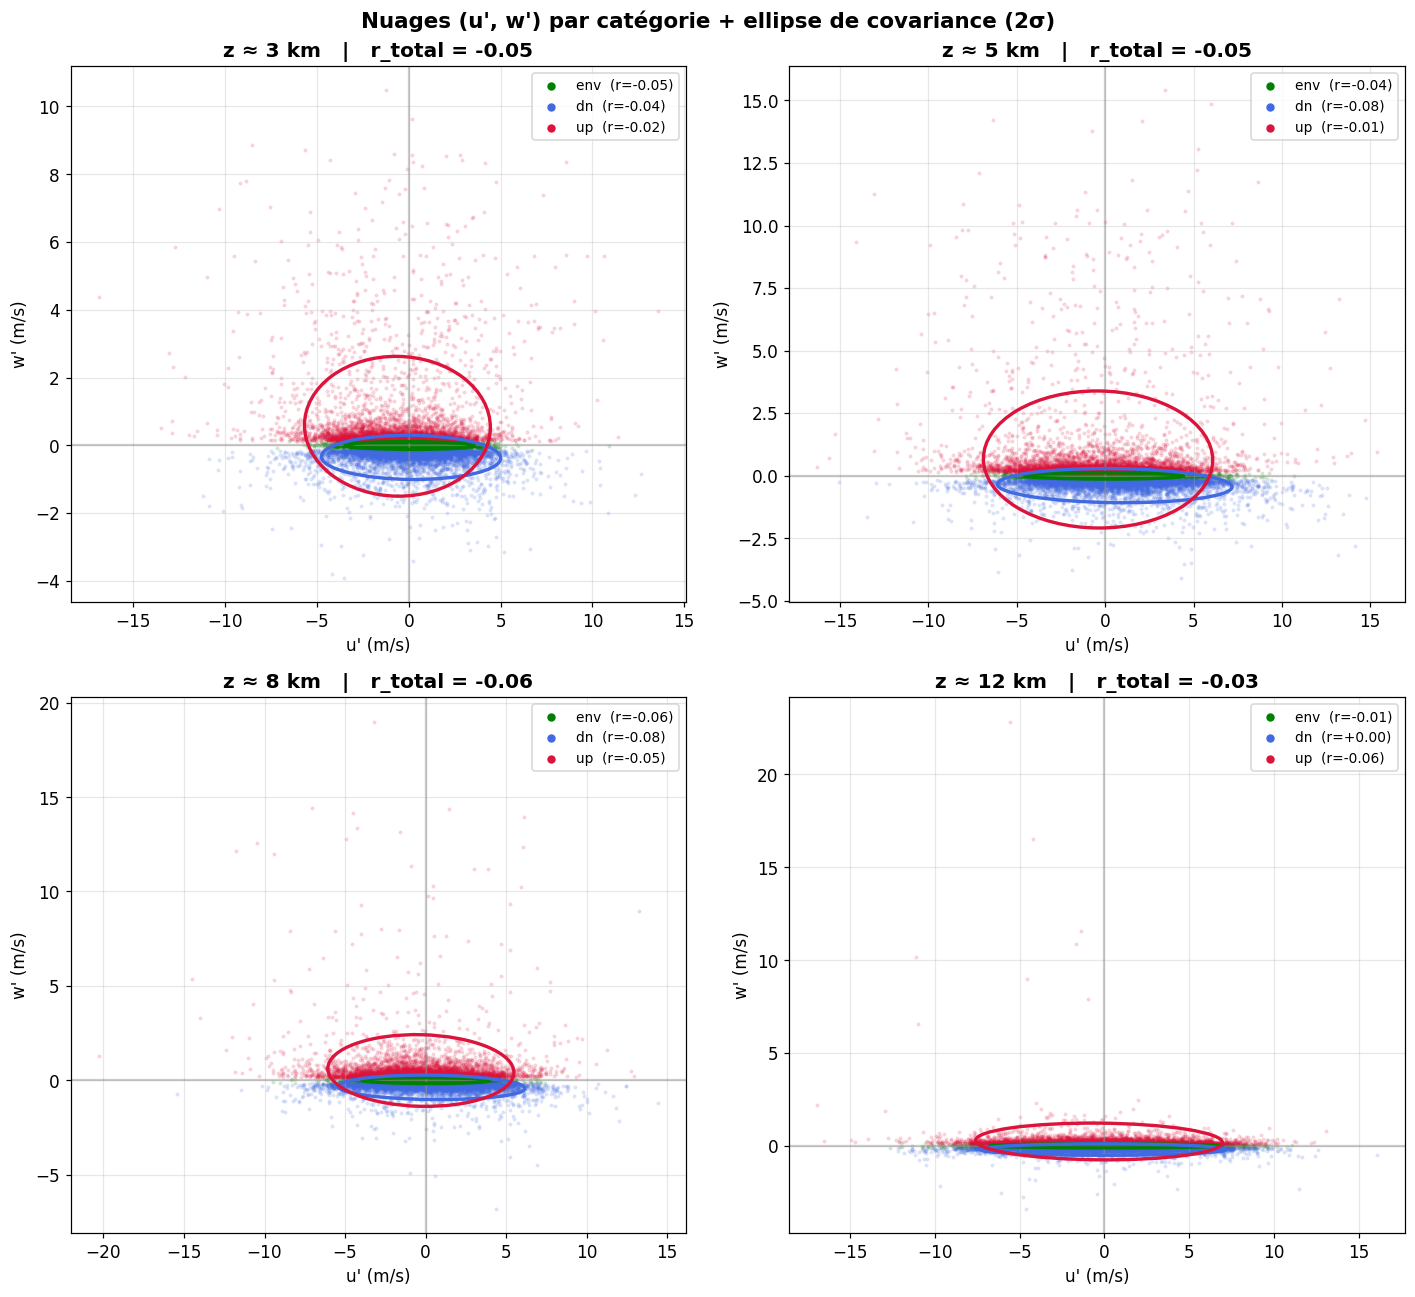

In [12]:
def cov_ellipse(ax, x, y, color, nstd=2.0):
    """Trace l'ellipse de covariance (nstd sigma) du nuage (x,y)."""
    if x.size < 5: return np.nan
    cov = np.cov(x, y); vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w_, h_ = 2*nstd*np.sqrt(np.maximum(vals, 0))
    e = Ellipse((x.mean(), y.mean()), w_, h_, angle=theta,
                edgecolor=color, facecolor='none', lw=2.2, zorder=5)
    ax.add_patch(e)
    return cov[0,1]/(np.sqrt(cov[0,0]*cov[1,1]) + 1e-12)   # correlation de la categorie

col = {'up':'crimson','dn':'royalblue','env':'green'}
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, ALT0 in zip(axes.ravel(), ALTS):
    for k in ('env','dn','up'):   # env dessous, up dessus
        if k not in samples[ALT0] or k.startswith('_'): continue
        uu, ww = samples[ALT0][k]
        ax.scatter(uu, ww, s=3, alpha=.12, color=col[k], rasterized=True)
        rk = cov_ellipse(ax, uu, ww, col[k])
        ax.scatter([], [], s=20, color=col[k], label=f'{k}  (r={rk:+.2f})')
    ax.axhline(0, color='grey', alpha=.4); ax.axvline(0, color='grey', alpha=.4)
    ax.set_xlabel("u' (m/s)"); ax.set_ylabel("w' (m/s)")
    ax.set_title(f"z ≈ {ALT0/1000:.0f} km   |   r_total = {samples[ALT0]['_r']:+.2f}",
                 fontweight='bold')
    ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=.3)
plt.suptitle("Nuages (u', w') par catégorie + ellipse de covariance (2σ)",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Objectif 2 — Comparer ma modélisation à celle de Romps 
##  Mise au point : que modélise *vraiment* le flux de masse de Romps ?

À la relecture du papier, une clarification s'impose, car ma première version comparait des
objets non comparables.

**Ce que Romps écrit.** Sa 2ᵉ équation bulk-plume est
$\;\rho\,\partial_t u=\partial_z\!\big[M(u-u_c)\big]\;$ (son Eq. 2). Le flux convectif de quantité
de mouvement qui y figure est donc

$$\Phi_{\rm Romps}=M\,(u-u_c)=M\,(u_e-u_c),$$

avec **un seul** flux de masse $M$, celui des **updrafts nuageux** (il l'écrit noir sur blanc :
*« convective downdrafts … are neglected in this theory for simplicity »*, section 2). Donc oui,
au niveau de la **formule**, Romps ne garde qu'un courant montant.

**Mais sa formule n'est pas « que du montant ».** Le terme
$M(u_e-u_c)$ encode déjà **deux** mouvements de masse couplés par la conservation :

- le **montant** dans le cœur : $+M$ qui porte $u_c$ ;
- la **subsidence compensatoire** de l'environnement : $-M$ qui porte $u_e$.


## 2.0 Observation de la subsidence

A1 — LE FLUX DE MASSE CREE-T-IL DE LA SUBSIDENCE ?
  flux montant   <M_up>  median = +0.0307 m/s  (doit etre >0)
  flux env       <M_env> median = -0.0025 m/s  (doit etre <0 = subsidence)
  flux dn        <M_dn>  median = -0.0266 m/s
  somme M_tot           median = +5.07e-03 m/s  (doit ~0 : conservation)

  part du montant compensee par l'ENV  : +7 %
  part du montant compensee par les DN : +76 %
  -> A1 VRAIE si M_env<0 et somme~0. Si comp_dn non negligeable, une partie
     de la compensation passe par des descendances actives, pas que la subsidence env.

A2 — CETTE SUBSIDENCE EST-ELLE UNIFORME ?
  <w>_env          median = -0.0028 m/s
  std(w) dans env  median = +0.0618 m/s
  ratio std/|mean| median = 21.3
     (>>1 => fluctuations >> subsidence moyenne => PAS uniforme)
  skewness w_env   median = +0.04
     (<0 marque => queue de descendances intenses => PAS uniforme)

  part du flux descendant portee par les 10% les plus intenses : 38 %
     (uniforme => ~10% ; structure => >>10%

/tmp/ipykernel_6091/2586339686.py:60: RuntimeWarning: divide by zero encountered in divide
  comp_env = -Menv / Mup
/tmp/ipykernel_6091/2586339686.py:61: RuntimeWarning: invalid value encountered in divide
  comp_dn  = -Mdn  / Mup


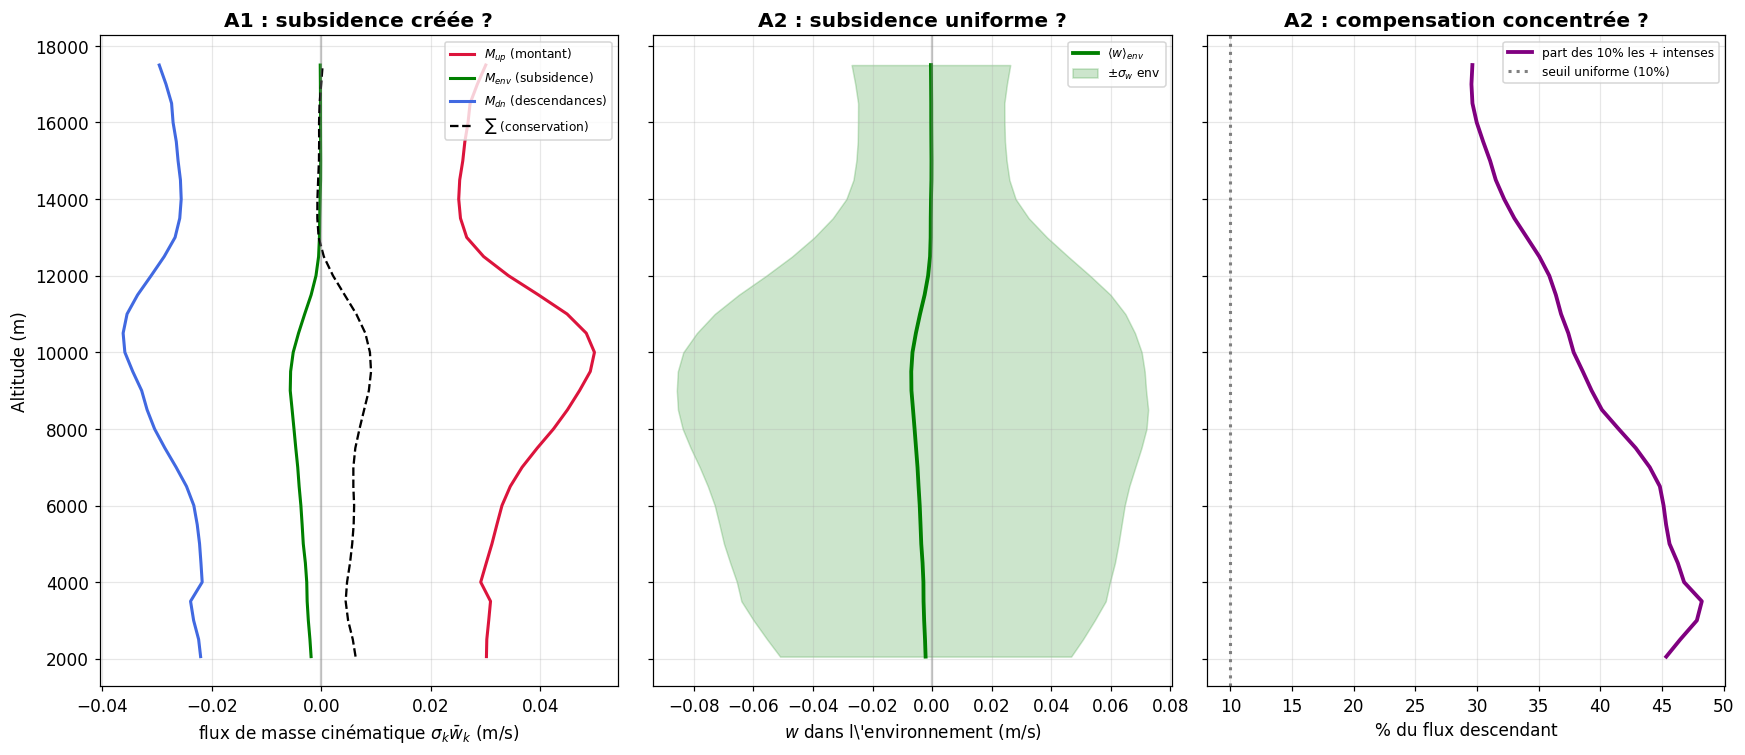

In [13]:
# ============================================================================
# TEST DES DEUX AFFIRMATIONS DE ROMPS
#   A1 : le flux de masse montant cree de la subsidence (conservation de masse)
#        -> sigma_env * wbar_env  doit compenser  sigma_up * wbar_up  (etre <0)
#   A2 : cette subsidence est UNIFORME
#        -> dans l'environnement, w doit etre peu disperse et sans queue de
#           descendances intenses (sinon la compensation est STRUCTUREE, pas uniforme)
# ============================================================================
reg = mh; C = float(C)

Mup   = np.full(n_z, np.nan)   # sigma_up * wbar_up   (flux de masse montant, >0)
Menv  = np.full(n_z, np.nan)   # sigma_env * wbar_env (subsidence env, doit etre <0)
Mdn   = np.full(n_z, np.nan)   # sigma_dn * wbar_dn   (descendances actives, <0)
Mtot  = np.full(n_z, np.nan)   # somme (doit ~ 0 : conservation)
wenv_mean = np.full(n_z, np.nan)  # <w>_env
wenv_std  = np.full(n_z, np.nan)  # ecart-type de w DANS l'environnement
wenv_skew = np.full(n_z, np.nan)  # skewness de w dans l'env (queue descendante ?)
# part de la compensation portee par des descendances "fortes" vs subsidence "douce"
frac_strong = np.full(n_z, np.nan)  # fraction du flux descendant portee par les 10% les plus intenses

ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    aMu=aMe=aMd=awm=aws=ask=afr=0.0; n=0
    for it in range(t_stat, n_t):
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        N = w.size
        ws, up, dn, env = classify(w, C)
        su, sd, se = up.sum()/N, dn.sum()/N, env.sum()/N
        aMu += su*(w[up].mean()  if up.any()  else 0.0)
        aMd += sd*(w[dn].mean()  if dn.any()  else 0.0)
        we = w[env]
        aMe += se*(we.mean() if we.size else 0.0)
        if we.size > 10:
            awm += we.mean(); aws += we.std()
            ask += ((we-we.mean())**3).mean()/(we.std()**3 + 1e-12)
        # --- A2 : concentration de la subsidence ---
        # toute la subsidence = points a w<0 (env + dn confondus), on regarde si elle
        # est portee par une minorite de points intenses (structuree) ou repartie (uniforme)
        wdesc = w[w < 0]
        if wdesc.size > 10:
            wsort = np.sort(wdesc)                 # du plus negatif au moins negatif
            k = max(1, int(0.10*wsort.size))       # les 10% les plus descendants
            afr += wsort[:k].sum() / wsort.sum()   # leur part du flux descendant total
        n += 1; del w
    Mup[iz]=aMu/n; Menv[iz]=aMe/n; Mdn[iz]=aMd/n; Mtot[iz]=(aMu+aMe+aMd)/n
    wenv_mean[iz]=awm/n; wenv_std[iz]=aws/n; wenv_skew[iz]=ask/n; frac_strong[iz]=afr/n
    gc.collect()
ds_w.close(); del ds_w; gc.collect()

s = band()
# ---------- A1 : la subsidence existe-t-elle, et compense-t-elle les cores ? ----------
print("="*70)
print("A1 — LE FLUX DE MASSE CREE-T-IL DE LA SUBSIDENCE ?")
print("="*70)
print(f"  flux montant   <M_up>  median = {np.nanmedian(Mup[s]):+.4f} m/s  (doit etre >0)")
print(f"  flux env       <M_env> median = {np.nanmedian(Menv[s]):+.4f} m/s  (doit etre <0 = subsidence)")
print(f"  flux dn        <M_dn>  median = {np.nanmedian(Mdn[s]):+.4f} m/s")
print(f"  somme M_tot           median = {np.nanmedian(Mtot[s]):+.2e} m/s  (doit ~0 : conservation)")
# ratio de compensation : quelle part du montant est compensee par l'env seul ?
comp_env = -Menv / Mup
comp_dn  = -Mdn  / Mup
print(f"\n  part du montant compensee par l'ENV  : {np.nanmedian(comp_env[s])*100:+.0f} %")
print(f"  part du montant compensee par les DN : {np.nanmedian(comp_dn[s])*100:+.0f} %")
print("  -> A1 VRAIE si M_env<0 et somme~0. Si comp_dn non negligeable, une partie")
print("     de la compensation passe par des descendances actives, pas que la subsidence env.")

# ---------- A2 : cette subsidence est-elle UNIFORME ? ----------
print("\n"+"="*70)
print("A2 — CETTE SUBSIDENCE EST-ELLE UNIFORME ?")
print("="*70)
print(f"  <w>_env          median = {np.nanmedian(wenv_mean[s]):+.4f} m/s")
print(f"  std(w) dans env  median = {np.nanmedian(wenv_std[s]):+.4f} m/s")
print(f"  ratio std/|mean| median = {np.nanmedian((wenv_std/np.abs(wenv_mean))[s]):.1f}")
print(f"     (>>1 => fluctuations >> subsidence moyenne => PAS uniforme)")
print(f"  skewness w_env   median = {np.nanmedian(wenv_skew[s]):+.2f}")
print(f"     (<0 marque => queue de descendances intenses => PAS uniforme)")
print(f"\n  part du flux descendant portee par les 10% les plus intenses :"
      f" {np.nanmedian(frac_strong[s])*100:.0f} %")
print(f"     (uniforme => ~10% ; structure => >>10%)")

# ============================ FIGURES ============================
zf = alt[s]
fig, ax = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

# (a) A1 : les flux de masse et leur somme
ax[0].plot(Mup[s],  zf, 'crimson',   lw=2, label=r'$M_{up}$ (montant)')
ax[0].plot(Menv[s], zf, 'green',     lw=2, label=r'$M_{env}$ (subsidence)')
ax[0].plot(Mdn[s],  zf, 'royalblue', lw=2, label=r'$M_{dn}$ (descendances)')
ax[0].plot(Mtot[s], zf, 'k--',       lw=1.5, label=r'$\sum$ (conservation)')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux de masse cinématique $\sigma_k\bar w_k$ (m/s)')
ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('A1 : subsidence créée ?', fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# (b) A2 : dispersion de w dans l'environnement
ax[1].plot(wenv_mean[s], zf, 'green', lw=2.5, label=r'$\langle w\rangle_{env}$')
ax[1].fill_betweenx(zf, (wenv_mean-wenv_std)[s], (wenv_mean+wenv_std)[s],
                    color='green', alpha=.2, label=r'$\pm\sigma_w$ env')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'$w$ dans l\'environnement (m/s)')
ax[1].set_title('A2 : subsidence uniforme ?', fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

# (c) A2 : concentration de la compensation
ax[2].plot(frac_strong[s]*100, zf, 'purple', lw=2.5, label='part des 10% les + intenses')
ax[2].axvline(10, color='grey', ls=':', lw=2, label='seuil uniforme (10%)')
ax[2].set_xlabel('% du flux descendant')
ax[2].set_title('A2 : compensation concentrée ?', fontweight='bold')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2.1 — Vérifier la conservation de la masse et reconstruire le flux de masse correct

In [14]:
# ---------------------------------------------------------------------------
# Flux de masse CORRECT (= T1 organise, 3 categories) vs Reynolds total
#   Phi_MF = sum_k rho0 sigma_k wbar_k (ubar_k - ubar)   avec  sum_k sigma_k wbar_k = 0
#   Controle : residu de masse  R_mass = sum_k sigma_k wbar_k  (doit ~ wbar global ~ 0)
# ---------------------------------------------------------------------------
reg = mh
Cs = np.array([0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0])

rey_tot   = np.full(n_z, np.nan)
PhiMF     = {C: np.full(n_z, np.nan) for C in Cs}
massres   = {C: np.full(n_z, np.nan) for C in Cs}   # residu de conservation de masse

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a_re = 0.0; aMF = {C:0.0 for C in Cs}; aMR = {C:0.0 for C in Cs}; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub, wb, N = u.mean(), w.mean(), u.size
        a_re += ((u-ub)*(w-wb)).mean()
        sw = w.std()
        for C in Cs:
            ws, up, dn, env = classify(w, C)
            acc = 0.0; mres = 0.0
            for msk in (up, dn, env):
                if not msk.any(): continue
                sig = msk.sum()/N
                wbar_k = w[msk].mean(); ubar_k = u[msk].mean()
                acc  += sig*wbar_k*(ubar_k-ub)        # T1 par categorie
                mres += sig*wbar_k                    # contribution au residu de masse
            aMF[C] += acc; aMR[C] += mres
        n += 1; del u, w
    rey_tot[iz] = rho0[iz]*a_re/n
    for C in Cs:
        PhiMF[C][iz]   = rho0[iz]*aMF[C]/n
        massres[C][iz] = aMR[C]/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

s = band()
scores = {C: nse(rey_tot, PhiMF[C], s) for C in Cs}
C_star = max(scores, key=scores.get)
print(f"{'C':>5} | {'NSE(Phi_MF=T1 vs Reynolds total)':>34}")
for C in Cs: print(f"{C:5.2f} | {scores[C]:+34.3f}")
print(f"\n>> C* (flux de masse 3-cat optimal) = {C_star}   (NSE = {scores[C_star]:+.3f})")

    C |   NSE(Phi_MF=T1 vs Reynolds total)
 0.10 |                             -0.136
 0.20 |                             +0.158
 0.30 |                             +0.342
 0.50 |                             +0.506
 0.80 |                             +0.550
 1.00 |                             +0.528
 1.20 |                             +0.486
 1.50 |                             +0.415
 2.00 |                             +0.291
 3.00 |                             +0.060

>> C* (flux de masse 3-cat optimal) = 0.8   (NSE = +0.550)


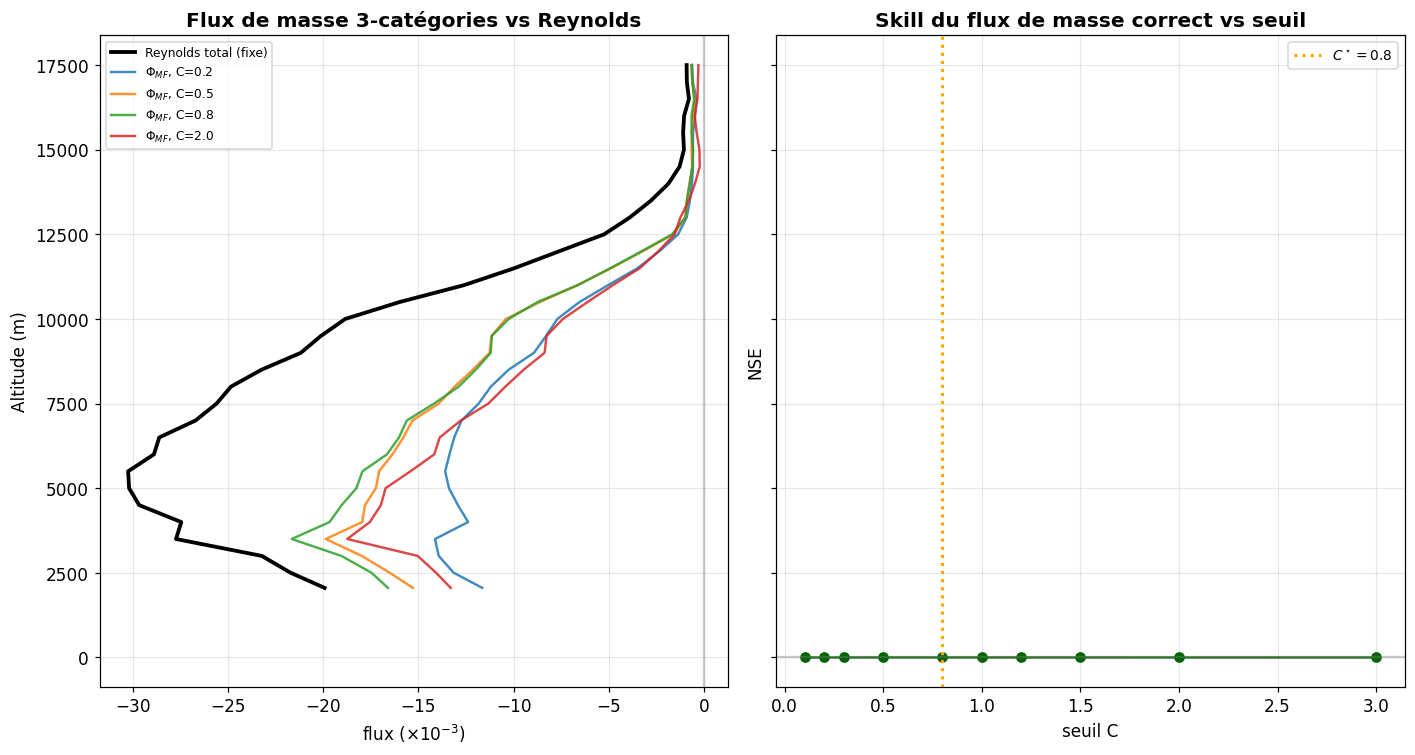

In [15]:
s = band(); zf = alt[s]; sc = 1e3
fig, ax = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
ax[0].plot(rey_tot[s]*sc, zf, 'k', lw=2.5, label='Reynolds total (fixe)')
for C in [0.2, 0.5, C_star, 2.0]:
    ax[0].plot(PhiMF[C][s]*sc, zf, lw=1.6, alpha=.85, label=fr'$\Phi_{{MF}}$, C={C}')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Flux de masse 3-catégories vs Reynolds', fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(list(Cs), [scores[C] for C in Cs], 'o-', color='darkgreen')
ax[1].axvline(C_star, color='orange', ls=':', lw=2, label=fr'$C^\star={C_star}$')
ax[1].axhline(0, color='grey', alpha=.4)
ax[1].set_xlabel('seuil C'); ax[1].set_ylabel('NSE')
ax[1].set_title('Skill du flux de masse correct vs seuil', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2.2 — Romps (2 catégories) vs ma version (3 catégories) : ce que la descendance explicite ajoute

On compare maintenant, **à seuil fixé $C^\star$**, deux réductions du même $\Phi_{\rm MF}$ :

- **Romps (2 cat.)** : on fusionne dn dans l'environnement → $\Phi_{R}=\rho_0\sigma_{up}\bar w_{up}(u_c-\bar u)+\rho_0\sigma_{rest}\bar w_{rest}(u_{rest}-\bar u)$, c'est-à-dire un cœur montant + tout le reste en « subsidence » moyenne. C'est l'esprit du 1-courant : la compensation est *uniforme*.
- **Ma version (3 cat.)** : up + dn + env séparés.

La différence isole *exactement* l'effet de **rendre la descendance explicite** au lieu de la
diluer dans une subsidence uniforme.

In [16]:
# ---------------------------------------------------------------------------
# Romps 2-cat (up + reste) vs 3-cat (up+dn+env), meme seuil C*, vs Reynolds total
# ---------------------------------------------------------------------------
reg = mh; C = float(C)
Phi_2cat = np.full(n_z, np.nan)   # Romps : up + reste(=dn+env fusionnes)
Phi_3cat = np.full(n_z, np.nan)   # moi   : up + dn + env
rey_t    = np.full(n_z, np.nan)
contrib_dn = np.full(n_z, np.nan) # part explicitement portee par dn dans 3-cat

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a2=a3=are=adn=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub, wb, N = u.mean(), w.mean(), u.size
        are += ((u-ub)*(w-wb)).mean()
        ws, up, dn, env = classify(w, C)
        rest = ~up                          # Romps : tout le non-updraft
        # --- 2 categories (Romps) ---
        for msk in (up, rest):
            if msk.any():
                sig = msk.sum()/N
                a2 += sig*w[msk].mean()*(u[msk].mean()-ub)
        # --- 3 categories (moi) ---
        for msk in (up, dn, env):
            if msk.any():
                sig = msk.sum()/N
                t = sig*(w[msk].mean() - w.mean())*(u[msk].mean()-ub)
                a3 += t
                if msk is dn: adn += t
        n+=1; del u,w
    Phi_2cat[iz]=rho0[iz]*a2/n; Phi_3cat[iz]=rho0[iz]*a3/n
    rey_t[iz]=rho0[iz]*are/n;   contrib_dn[iz]=rho0[iz]*adn/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

s = band()
print(f'NSE Romps (2 cat, up+subsidence) vs Reynolds = {nse(rey_t, Phi_2cat, s):+.3f}')
print(f'NSE moi   (3 cat, up+dn+env)     vs Reynolds = {nse(rey_t, Phi_3cat, s):+.3f}')
print(f'part mediane portee explicitement par dn (3-cat) = '
      f'{np.nanmedian((contrib_dn/Phi_3cat)[s])*100:+.0f} %')

NSE Romps (2 cat, up+subsidence) vs Reynolds = -0.200
NSE moi   (3 cat, up+dn+env)     vs Reynolds = +0.291
part mediane portee explicitement par dn (3-cat) = +33 %


/tmp/ipykernel_6091/3608761740.py:42: RuntimeWarning: invalid value encountered in divide
  f'{np.nanmedian((contrib_dn/Phi_3cat)[s])*100:+.0f} %')


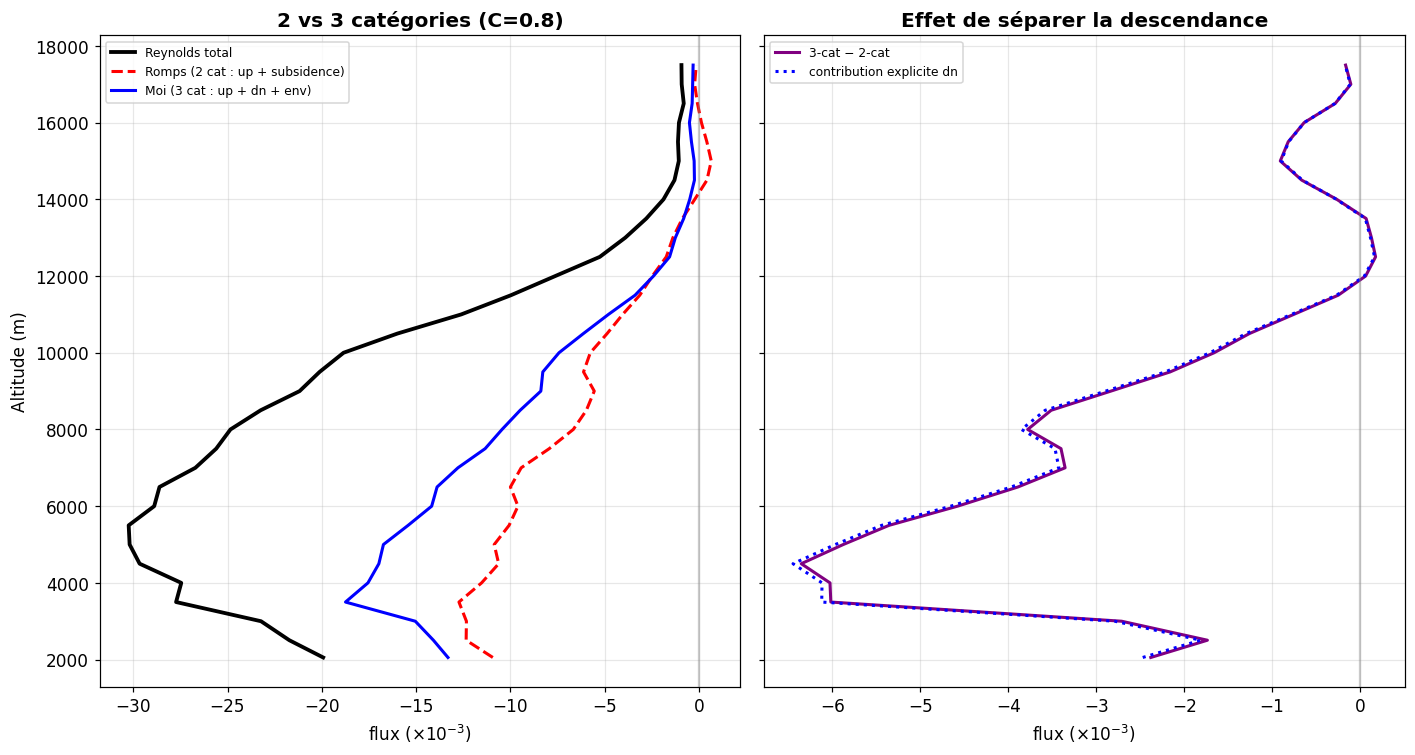

In [17]:
s = band(); zf = alt[s]; sc = 1e3
fig, ax = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
ax[0].plot(rey_t[s]*sc,    zf, 'k',  lw=2.5, label='Reynolds total')
ax[0].plot(Phi_2cat[s]*sc, zf, 'r--',lw=2,   label='Romps (2 cat : up + subsidence)')
ax[0].plot(Phi_3cat[s]*sc, zf, 'b-', lw=2,   label='Moi (3 cat : up + dn + env)')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title(f'2 vs 3 catégories (C={C_star})', fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot((Phi_3cat-Phi_2cat)[s]*sc, zf, 'purple', lw=2, label='3-cat − 2-cat')
ax[1].plot(contrib_dn[s]*sc, zf, 'b:', lw=2, label='contribution explicite dn')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'flux ($\times10^{-3}$)')
ax[1].set_title("Effet de séparer la descendance", fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2.3 — La logique bulk-plume : 3 équations, entraînement effectif, et la place des 2 courants

On teste enfin la **logique** de Romps sur les profils diagnostiqués (et non plus seulement le
flux). Les 3 équations (pour $u$) :

$$\partial_z M=(\varepsilon-\delta)M,\qquad
\rho\,\partial_t u=\partial_z[M(u_e-u_c)],\qquad
\partial_z u_c=\varepsilon_{\rm eff}(u_e-u_c).$$

On diagnostique $\varepsilon_{\rm eff}=\partial_z u_c/(u_e-u_c)$ (son Eq. 18) et on regarde si une
relation analogue $\partial_z u_d=\varepsilon_d(u_c-u_d)$ tient pour la descendance.


In [18]:
# ---------------------------------------------------------------------------
# Profils conditionnels + entrainement effectif, AVEC masque anti-singularite
# ---------------------------------------------------------------------------
reg = mh; C = float(C_star)
uc_p=np.full(n_z,np.nan); ud_p=np.full(n_z,np.nan); ue_p=np.full(n_z,np.nan)
Mc_p=np.full(n_z,np.nan); Md_p=np.full(n_z,np.nan)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    auc=aud=aue=aMc=aMd=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub = u.mean()
        ws, up, dn, env = classify(w, C)
        auc += cond_mean(u, up, ub); aud += cond_mean(u, dn, ub); aue += cond_mean(u, env, ub)
        aMc += rho0[iz]*(w*up).mean(); aMd += rho0[iz]*(w*dn).mean()
        n+=1; del u,w
    uc_p[iz]=auc/n; ud_p[iz]=aud/n; ue_p[iz]=aue/n; Mc_p[iz]=aMc/n; Md_p[iz]=aMd/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

duc=np.gradient(uc_p,alt); dud=np.gradient(ud_p,alt); dMc=np.gradient(Mc_p,alt)
# masque anti-singularite : contraste suffisant
DU_MIN = 0.15  # m/s
den_c = ue_p-uc_p; den_d = uc_p-ud_p
eps_c = np.where(np.abs(den_c)>DU_MIN, duc/den_c, np.nan)
eps_d = np.where(np.abs(den_d)>DU_MIN, dud/den_d, np.nan)
delta_c = eps_c - dMc/np.where(np.abs(Mc_p)>1e-9, Mc_p, np.nan)

s = band()
print(f'contraste |u_e-u_c| median = {np.nanmedian(np.abs(den_c)[s]):.2f} m/s')
print(f'eps_c effectif (masque) median = {np.nanmedian(eps_c[s])*1e3:+.3f} km^-1')
print(f'eps_d effectif (masque) median = {np.nanmedian(eps_d[s])*1e3:+.3f} km^-1')
print(f'(Romps : ~1.5 km^-1 pour le vent, ~0.4 pour un traceur passif)')

contraste |u_e-u_c| median = 0.54 m/s
eps_c effectif (masque) median = -0.034 km^-1
eps_d effectif (masque) median = +0.080 km^-1
(Romps : ~1.5 km^-1 pour le vent, ~0.4 pour un traceur passif)


/tmp/ipykernel_6091/4171548654.py:27: RuntimeWarning: divide by zero encountered in divide
  eps_c = np.where(np.abs(den_c)>DU_MIN, duc/den_c, np.nan)
/tmp/ipykernel_6091/4171548654.py:28: RuntimeWarning: divide by zero encountered in divide
  eps_d = np.where(np.abs(den_d)>DU_MIN, dud/den_d, np.nan)


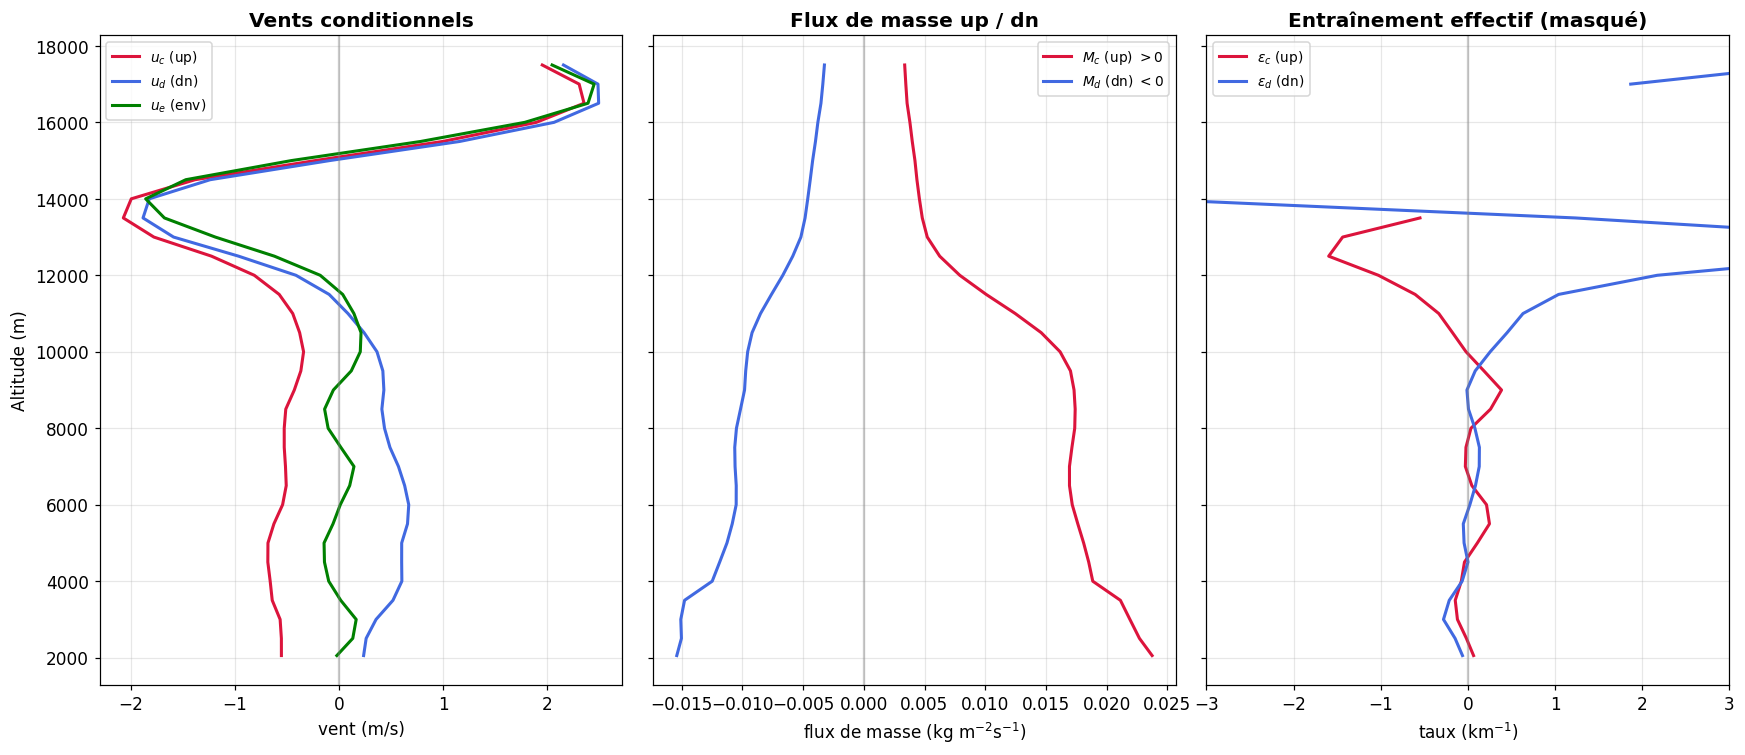

In [19]:
s = band(); zf = alt[s]
fig, ax = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

ax[0].plot(uc_p[s], zf, 'crimson',   lw=2, label=r'$u_c$ (up)')
ax[0].plot(ud_p[s], zf, 'royalblue', lw=2, label=r'$u_d$ (dn)')
ax[0].plot(ue_p[s], zf, 'green',     lw=2, label=r'$u_e$ (env)')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel('vent (m/s)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Vents conditionnels', fontweight='bold'); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

ax[1].plot(Mc_p[s], zf, 'crimson',   lw=2, label=r'$M_c$ (up) $>0$')
ax[1].plot(Md_p[s], zf, 'royalblue', lw=2, label=r'$M_d$ (dn) $<0$')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'flux de masse (kg m$^{-2}$s$^{-1}$)')
ax[1].set_title('Flux de masse up / dn', fontweight='bold'); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

ax[2].plot(eps_c[s]*1e3, zf, 'crimson',   lw=2, label=r'$\varepsilon_c$ (up)')
ax[2].plot(eps_d[s]*1e3, zf, 'royalblue', lw=2, label=r'$\varepsilon_d$ (dn)')
ax[2].axvline(0, color='grey', alpha=.4); ax[2].set_xlim(-3, 3)
ax[2].set_xlabel(r'taux (km$^{-1}$)')
ax[2].set_title('Entraînement effectif (masqué)', fontweight='bold')
ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## Verification sur schéma global

COMPARAISON GLOBALE (domaine entier, cadre valable de Romps)
  fraction nuageuse globale mediane sigma_c = 0.0020
     (hypothese Romps 'faible aire' OK si << 1)
  NSE Romps (1 courant) vs Reynolds global = -4.314
  NSE toi 2-cat         vs Reynolds global = -0.289
  NSE toi 3-cat         vs Reynolds global = +0.385

  RAPPEL region humide seule (ton notebook) : a comparer pour voir
  si l'ecart Romps/Reynolds etait un artefact de masque ou un vrai defaut.


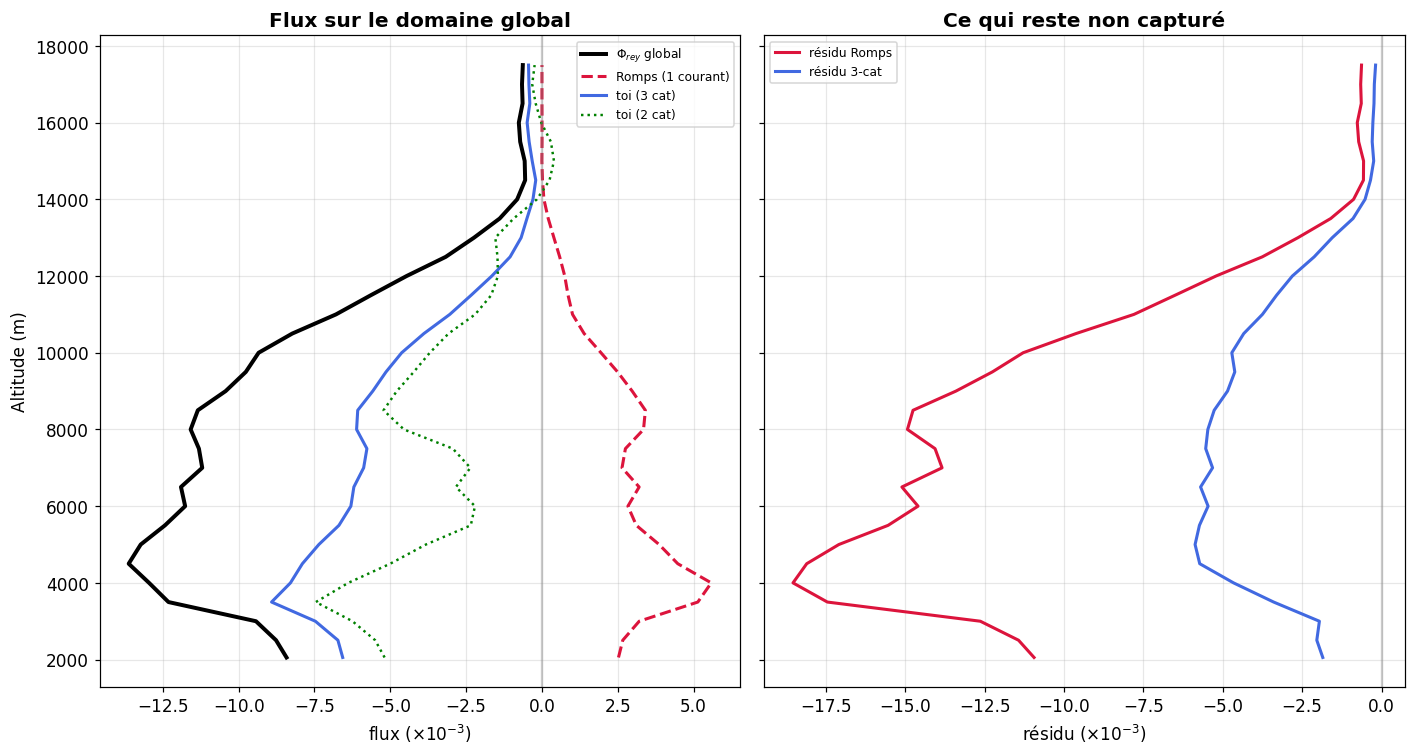

In [20]:
# ============================================================================
# COMPARAISON SUR LE DOMAINE GLOBAL (sans masque humide/sec)
#   C'est le cadre ou la formule de Romps est VALABLE (domaine periodique
#   homogene, faible fraction nuageuse, env = moyenne de domaine).
#   On compare : Reynolds total | Romps (1 courant) | toi (3 cat) | toi (2 cat)
# ============================================================================
C = float(C_star)
rey_g   = np.full(n_z, np.nan)   # Reynolds total, domaine entier
Phi_R   = np.full(n_z, np.nan)   # Romps : M(ubar - u_c), cloudy updrafts
Phi_2   = np.full(n_z, np.nan)   # toi 2-cat (up + reste)
Phi_3   = np.full(n_z, np.nan)   # toi 3-cat (up + dn + env)
sigc_g  = np.full(n_z, np.nan)   # fraction nuageuse globale (verif "faible aire")

import os
have_clw = os.path.exists(path3d('clw')); have_cli = os.path.exists(path3d('cli'))
USE_QC = have_clw
if USE_QC:
    dsc = xr.open_dataset(path3d('clw'))
    dsi = xr.open_dataset(path3d('cli')) if have_cli else None
W_CLOUD, QC_MIN = 1.0, 1e-5      # definition Romps exacte

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    are=aR=a2=a3=asg=0.0; n=0
    for it in range(t_stat, n_t):
        # --- PAS DE MASQUE : tout le plan horizontal ---
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values.ravel()
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values.ravel()
        ub, wb, N = u.mean(), w.mean(), u.size
        # Reynolds total global
        are += ((u-ub)*(w-wb)).mean()
        # --- Romps : cloudy updrafts sur le domaine entier ---
        if USE_QC:
            qc = dsc['clw'].isel({dim_t:it, dim_z:iz}).values.ravel()
            if dsi is not None: qc = qc + dsi['cli'].isel({dim_t:it, dim_z:iz}).values.ravel()
            cloud = (w > W_CLOUD) & (qc > QC_MIN)
        else:
            cloud = (w > W_CLOUD)
        if cloud.any():
            sig_c = cloud.sum()/N
            M = rho0[iz]*sig_c*w[cloud].mean()
            aR  += M*(ub - u[cloud].mean())     # M(ubar - u_c)
            asg += sig_c
        # --- tes flux top-hat, partition globale (seuil sur w) ---
        ws, up, dn, env = classify(w, C)
        rest = ~up
        for msk in (up, rest):
            if msk.any():
                a2 += (msk.sum()/N)*w[msk].mean()*(u[msk].mean()-ub)
        for msk in (up, dn, env):
            if msk.any():
                a3 += (msk.sum()/N)*w[msk].mean()*(u[msk].mean()-ub)
        n+=1; del u, w
    rey_g[iz]=rho0[iz]*are/n; Phi_R[iz]=aR/n
    Phi_2[iz]=rho0[iz]*a2/n;  Phi_3[iz]=rho0[iz]*a3/n
    sigc_g[iz]=asg/n
    gc.collect()
ds_u.close(); ds_w.close()
if USE_QC:
    dsc.close()
    if dsi is not None: dsi.close()
del ds_u, ds_w; gc.collect()

# --- scores + verif faible fraction nuageuse ---
s = band()
print("="*60)
print("COMPARAISON GLOBALE (domaine entier, cadre valable de Romps)")
print("="*60)
print(f"  fraction nuageuse globale mediane sigma_c = {np.nanmedian(sigc_g[s]):.4f}")
print(f"     (hypothese Romps 'faible aire' OK si << 1)")
print(f"  NSE Romps (1 courant) vs Reynolds global = {nse(rey_g, Phi_R, s):+.3f}")
print(f"  NSE toi 2-cat         vs Reynolds global = {nse(rey_g, Phi_2, s):+.3f}")
print(f"  NSE toi 3-cat         vs Reynolds global = {nse(rey_g, Phi_3, s):+.3f}")
print(f"\n  RAPPEL region humide seule (ton notebook) : a comparer pour voir")
print(f"  si l'ecart Romps/Reynolds etait un artefact de masque ou un vrai defaut.")

# --- figure ---
zf=alt[s]; sc=1e3
fig, ax = plt.subplots(1, 2, figsize=(13,7), sharey=True)
ax[0].plot(rey_g[s]*sc, zf,'k',lw=2.6,label=r'$\Phi_{rey}$ global')
ax[0].plot(Phi_R[s]*sc, zf,'crimson',lw=2,ls='--',label='Romps (1 courant)')
ax[0].plot(Phi_3[s]*sc, zf,'royalblue',lw=2,label='toi (3 cat)')
ax[0].plot(Phi_2[s]*sc, zf,'green',lw=1.6,ls=':',label='toi (2 cat)')
ax[0].axvline(0,color='grey',alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Flux sur le domaine global',fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot((rey_g-Phi_R)[s]*sc, zf,'crimson',lw=2,label='résidu Romps')
ax[1].plot((rey_g-Phi_3)[s]*sc, zf,'royalblue',lw=2,label='résidu 3-cat')
ax[1].axvline(0,color='grey',alpha=.4)
ax[1].set_xlabel(r'résidu ($\times10^{-3}$)')
ax[1].set_title('Ce qui reste non capturé',fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

TENDANCES (divergence) — terme de Navier-Stokes
  NSE Romps (tendance) vs Reynolds = -2.465
  NSE 3-cat (tendance) vs Reynolds = +0.520
  (comparer aux NSE EN FLUX : la divergence amplifie les écarts de pente)


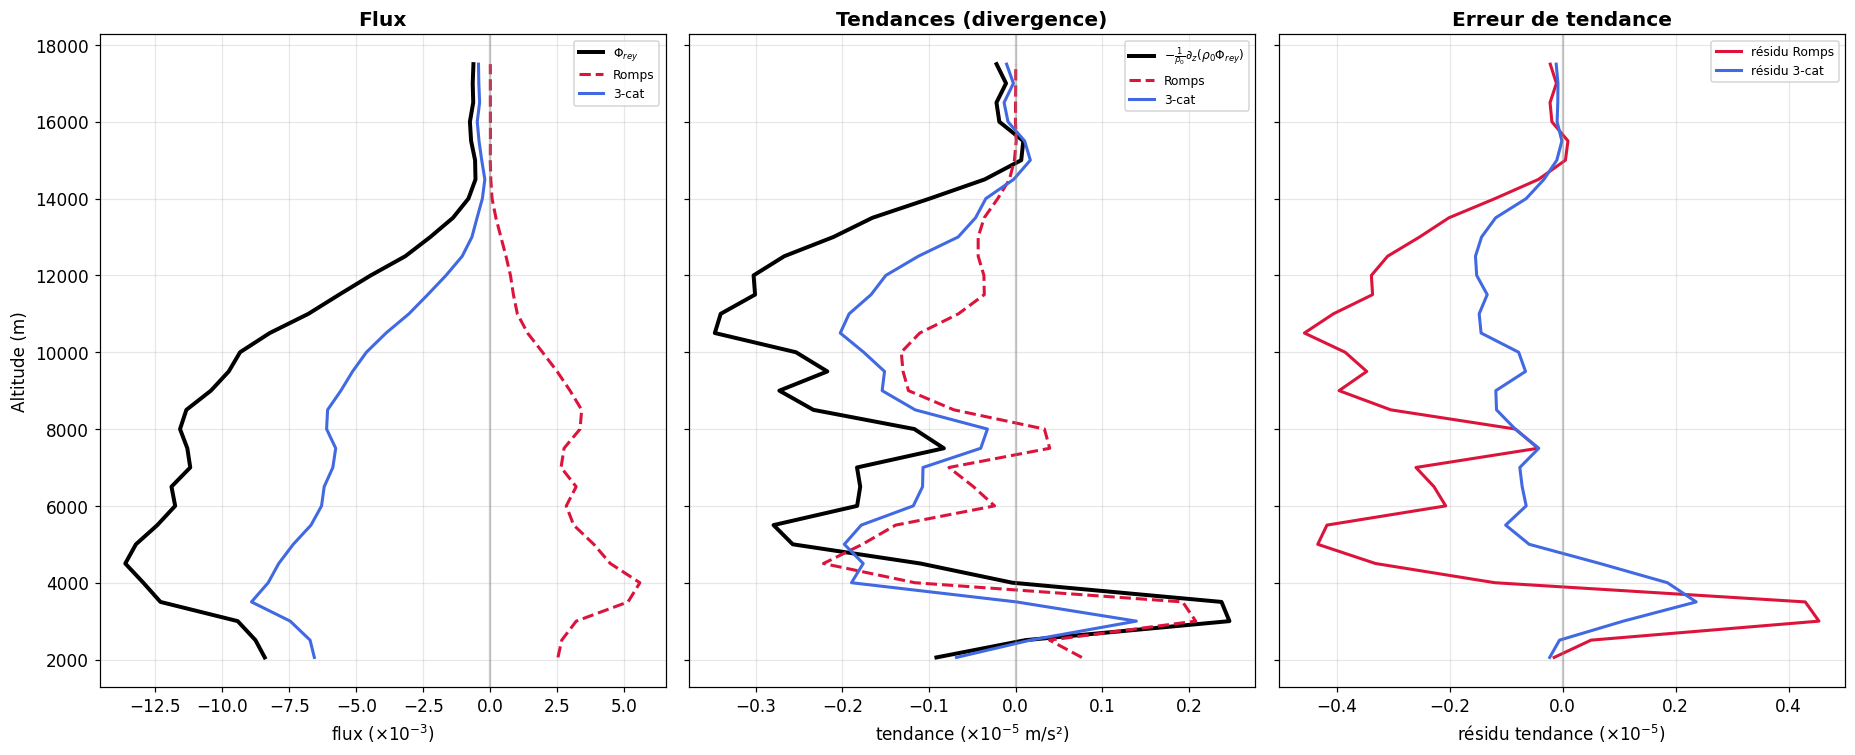

In [22]:
# ============================================================================
# TENDANCES (divergence verticale des flux) — le vrai terme de Navier-Stokes
#   tend = -1/rho0 * d/dz ( rho0 * Phi )
#   On compare la tendance Reynolds a la tendance Romps et a la tienne (3-cat).
#   (reutilise rey_g, Phi_R, Phi_3 du run GLOBAL precedent)
# ============================================================================
def tendance(Phi):
    """-1/rho0 d/dz(rho0 * Phi), differences finies centrees sur la grille alt."""
    return -np.gradient(rho0*Phi, alt) / rho0

tend_rey = tendance(rey_g)
tend_R   = tendance(Phi_R)
tend_3   = tendance(Phi_3)

s = band(); zf = alt[s]
print("="*60)
print("TENDANCES (divergence) — terme de Navier-Stokes")
print("="*60)
print(f"  NSE Romps (tendance) vs Reynolds = {nse(tend_rey, tend_R, s):+.3f}")
print(f"  NSE 3-cat (tendance) vs Reynolds = {nse(tend_rey, tend_3, s):+.3f}")
print(f"  (comparer aux NSE EN FLUX : la divergence amplifie les écarts de pente)")

sc = 1e5   # tendances ~ 1e-5 m/s^2
fig, ax = plt.subplots(1, 3, figsize=(17, 7), sharey=True)

# (a) les flux (rappel)
ax[0].plot(rey_g[s]*1e3, zf, 'k', lw=2.6, label=r'$\Phi_{rey}$')
ax[0].plot(Phi_R[s]*1e3, zf, 'crimson', lw=2, ls='--', label='Romps')
ax[0].plot(Phi_3[s]*1e3, zf, 'royalblue', lw=2, label='3-cat')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Flux', fontweight='bold'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# (b) les tendances = ce qui entre vraiment dans Navier-Stokes
ax[1].plot(tend_rey[s]*sc, zf, 'k', lw=2.6, label=r'$-\frac{1}{\rho_0}\partial_z(\rho_0\Phi_{rey})$')
ax[1].plot(-tend_R[s]*sc,   zf, 'crimson', lw=2, ls='--', label='Romps')
ax[1].plot(tend_3[s]*sc,   zf, 'royalblue', lw=2, label='3-cat')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'tendance ($\times10^{-5}$ m/s²)')
ax[1].set_title('Tendances (divergence)', fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

# (c) residus de tendance
ax[2].plot((tend_rey-tend_R)[s]*sc, zf, 'crimson', lw=2, label='résidu Romps')
ax[2].plot((tend_rey-tend_3)[s]*sc, zf, 'royalblue', lw=2, label='résidu 3-cat')
ax[2].axvline(0, color='grey', alpha=.4)
ax[2].set_xlabel(r'résidu tendance ($\times10^{-5}$)')
ax[2].set_title('Erreur de tendance', fontweight='bold')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()